# Plot and compare atmospheric forcing

Started 2023-04-21

by Eva Lieungh, adapted from [LSP notebook](https://github.com/NorESMhub/noresm-land-sites-platform/tree/main/notebooks/plot_input_data). 

Plots to visualize some of the model inputs for atmospheric forcing, i.e., the dataset providing climatic observations driving model processes such as photosynthesis or evaporation.

Print the current working directory to know where to define paths from:

In [39]:
%%bash
pwd

/mnt/c/Users/evaler/OneDrive - Universitetet i Oslo/Eva/PHD/3_FATES_INCLINE/FATES_INCLINE/src/analysis_and_plotting


In [40]:
from pathlib import Path
import matplotlib.pyplot as plt
import xarray as xr
import time
import glob

Read in data

In [41]:
# set path for all input data folders
#inputdata_path = f"../../data/inputdata"
inputdata_path = f"../../../../../../../model_output/inputdata/inputdata/"

# Add full inputdata folder names
file_path_cold = f"{inputdata_path}skj_pt_gswp3-cold"
file_path_otc_c = f"{inputdata_path}skj_pt_gswp3-otc"
file_path_warm = f"{inputdata_path}skj_pt_gswp3"
file_path_otc_w = f"{inputdata_path}skj_pt_gswp3-warm-otc"

file_paths = {
    'cold': file_path_cold,
    'otc_c': file_path_otc_c,
    'warm': file_path_warm,
    'otc_w': file_path_otc_w
}

# print one to see if it looks correct
file_path_cold

'../../../../../../../model_output/inputdata/inputdata/skj_pt_gswp3-cold'

Open and combine all the monthly atmospheric NetCDF files into an xarray dataset. Read only temperature. Solar radiation and precipitation should be identical between the data sets.

In [42]:
data = {}

# take the time of this process, could take some minutes
start_time = time.time()

for dataset, path in file_paths.items():
    data_paths = glob.glob(f"{path}/datmdata/*TPQWL*.nc")
    data[dataset] = xr.open_mfdataset(data_paths, 
                                      combine='by_coords', 
                                      decode_times=True)

print(f"--- Time it took to read the data: {round(float(time.time() - start_time), 3)} seconds ---")

--- Time it took to read the data: 262.646 seconds ---


Specify custom start and end dates for plotting a short time period with the original temporal resolution, i.e. in 3 hourly timesteps. It should generally be a year or less to maintain readability. Must be within the time range of the data, 1901-01-01 to 2013-12-31 for GSWP3.

In [43]:
subset_time_start = '2013-01-01'  # Format: YYYY-MM-DD
subset_time_end = '2013-12-31'  # Format: YYYY-MM-DD

In [44]:
# Create case folder for output plots if necessary
out_dir_path =  Path("../../results/figures/forcing_data")

if not out_dir_path.is_dir():
    out_dir_path.mkdir(parents=True, exist_ok=True)

In [46]:
# Set general plotting options
DPI = 300
TICK_LABEL_FONT_SIZE = 12
AX_LABEL_FONT_SIZE = 14
TITLE_FONT_SIZE = 16

## Full dataset period

In [47]:
# Print dataset info
data

{'cold': <xarray.Dataset>
 Dimensions:  (time: 332880, lat: 1, lon: 1, scalar: 1)
 Coordinates:
   * time     (time) object 1901-01-01 01:30:00 ... 2014-12-31 22:30:00
   * lon      (lon) float32 6.25
   * lat      (lat) float32 60.75
 Dimensions without coordinates: scalar
 Data variables:
     TBOT     (time, lat, lon) float64 dask.array<chunksize=(248, 1, 1), meta=np.ndarray>
     LONGXY   (time, lat, lon) float32 dask.array<chunksize=(248, 1, 1), meta=np.ndarray>
     LATIXY   (time, lat, lon) float32 dask.array<chunksize=(248, 1, 1), meta=np.ndarray>
     EDGEE    (time, scalar, lat, lon) float32 dask.array<chunksize=(248, 1, 1, 1), meta=np.ndarray>
     EDGEW    (time, scalar, lat, lon) float32 dask.array<chunksize=(248, 1, 1, 1), meta=np.ndarray>
     EDGES    (time, scalar, lat, lon) float32 dask.array<chunksize=(248, 1, 1, 1), meta=np.ndarray>
     EDGEN    (time, scalar, lat, lon) float32 dask.array<chunksize=(248, 1, 1, 1), meta=np.ndarray>
     PSRF     (time, lat, lon) flo

#### Annual temperature comparison

In [49]:
datasets = [
    'cold',
    'otc_c',
    'warm',
    'otc_w',
]

In [57]:
temp_annual_mean = {}

for dat in datasets:
    temp_annual_mean[dat] = data[dat]["TBOT"].resample(time='1Y').mean() - 273.15

In [72]:
temp_annual_mean["cold"]["time"]

<xarray.DataArray 'time' (time: 114)>
array([cftime.DatetimeNoLeap(1901, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1902, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1903, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1904, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1905, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1906, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1907, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1908, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1909, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1910, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1911, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1912, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1913, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1914, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1915, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1916, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1917, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1918, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1919, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1920, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1921, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1922, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1923, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1924, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1925, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1926, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1927, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1928, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1929, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1930, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1931, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1932, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1933, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1934, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1935, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1936, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1937, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1938, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1939, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1940, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1941, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1942, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1943, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1944, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1945, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1946, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1947, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1948, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1949, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1950, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1951, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1952, 12, 31, 0, 0, 0, 0, has_year_zero=True),
       cft

In [74]:
#temp_annual_mean["cold"].values
#range(len(temp_annual_mean["cold"]["time"]))
range(len(temp_annual_mean["cold"].values))

range(0, 114)

ValueError: x and y can be no greater than 2D, but have shapes (114,) and (114, 1, 1)

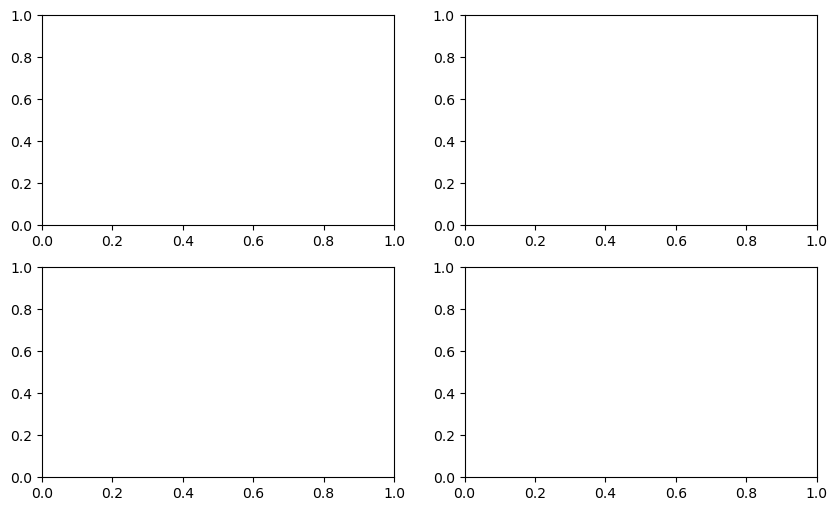

In [ ]:
# Instantiate plot
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(10, 6)
)


# Plot in loop
for i, dat in enumerate(datasets):
    ax = axes.flatten()[i]
    # subset variable from data
    temp = temp_annual_mean[dat]
    ax.plot(range(len(temp["time"])), 
            temp.values,
            color="blue") 
    ax.set_title(dat)
    ax.set_xlabel("Simulation year")
    ax.set_ylabel(f"Aboveground vegetation carbon [{temp['FATES_VEGC_ABOVEGROUND'].units}]")
    # set y axis limits
#    ax.set_ylim([0, 0.020])

plt.tight_layout()  # Adjust spacing between subplots
plt.show()  # Show the plot


#ax1.plot(range(len(temp_annual_mean["cold"].time)),
#         temp_annual_mean["cold"].values.flatten(),
#         color="#3E0BF4",
#         linewidth=2,
#         label="Annual mean temperature [°C]"
#       )
#

# Disable x axes for subplots 1 and 2
#ax1.get_xaxis().set_visible(False)
#ax2.get_xaxis().set_visible(False)

# Save figure
fig.tight_layout()
fig.savefig(fname=f"{out_dir_path}/atmosphere_yearly_temp.png", format='png')

---
## Short period

In [ ]:
atm_forcing_data

### Temperature, precipitation, total radiation, longwave radiation, humidity, wind, atm. pressure 

In [ ]:
atm_forcing_subset = atm_forcing_data.sel(
    time=slice(subset_time_start, subset_time_end)
)
atm_forcing_subset

In [ ]:
variable_list = []

# Temperature, convert from K to °C
temp_subset = (atm_forcing_subset["TBOT"] - 273.15).dropna(dim="time")
variable_list.append(temp_subset)

# Precipitation, convert from [mm H2O / sec] to total [mm] (data temp. resolution: 3h=10800s), calculate cumulative sum
precip_subset = (atm_forcing_subset["PRECTmms"] * 10800).cumsum().dropna(dim="time")
variable_list.append(precip_subset)

# Total incident radiation
radation_total_subset = atm_forcing_subset["FSDS"].dropna(dim="time")
variable_list.append(radation_total_subset)

# Incident longwave radiation
radation_longwave_subset = atm_forcing_subset["FLDS"].dropna(dim="time")
variable_list.append(radation_longwave_subset)

# Specific humidity
humidity_subset = atm_forcing_subset["QBOT"].dropna(dim="time")
variable_list.append(humidity_subset)

# Wind speed
wind_subset = atm_forcing_subset["WIND"].dropna(dim="time")
variable_list.append(wind_subset)

# Atm. pressure, convert to hPa
pressure_subset = (atm_forcing_subset["PSRF"] * 0.01).dropna(dim="time")
variable_list.append(pressure_subset)

In [ ]:
# Label dictionary
subset_plot_dict = {
    "TBOT": {
        "y_axis": "2m air temperature",
        "unit": "[°C]",
        "color": "#C0392B",
    },
    "PRECTmms": {
        "y_axis": "Cumulative precipitation",
        "unit": "[mm]",
        "color": "#0047AB",
    },
    "FSDS": {
        "y_axis": "Total incident solar radiation",
        "unit": "[W/m²]",
        "color": "#28282B",
    },
    "FLDS": {
        "y_axis": "Incident longwave radiation",
        "unit": "[W/m²]",
        "color": "#FE5654",
    },
    "QBOT": {
        "y_axis": "2m specific humidity",
        "unit": "[kg/kg]",
        "color": "#8EA9F6",
    },
    "WIND": {
        "y_axis": "2m wind speed",
        "unit": "[m/s]",
        "color": "#F00BF3",
    },
    "PSRF": {
        "y_axis": "Surface pressure",
        "unit": "[hPa]",
        "color": "#6B6B6B",
    },
}

In [ ]:
# Create plots for each variable
for variable in variable_list:
    
    # Get plot settings for current variable
    current_var_dict = subset_plot_dict.get(variable.name)
    
    # Instantiate plot
    fig, ax = plt.subplots(figsize=(6, 6), dpi=DPI)

    ax.plot(variable.time,
            variable.values.flatten(),
            color=current_var_dict.get('color'),
            linewidth=2,
           )
    
    # Other plot layout settings
    ax.set_title(f"{site_code}: {variable.name} - GSWP3 forcing\n{subset_time_start} -- {subset_time_end}", size=TITLE_FONT_SIZE)

    ax.set_ylabel(current_var_dict.get('y_axis') + " " + current_var_dict.get('unit'),
                  fontsize=AX_LABEL_FONT_SIZE)
    ax.set_xlabel("Date", fontsize=AX_LABEL_FONT_SIZE)

    ax.tick_params(axis='both', which='major', labelsize=TICK_LABEL_FONT_SIZE)

    # Save figure
    fig.tight_layout()
    fig.savefig(fname=f"{out_dir_path}/atmosphere_{variable.name}_{subset_time_start}_to_{subset_time_end}.png", format='png')